<a href="https://colab.research.google.com/github/tejas1824/CSL701-Roll_No30_Machine-Learning-Lab/blob/main/TejasExperiment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name :Tejas Sanjiv Mochemadkar

Batch :CE02


Roll Number :CE30



### **Aim**

To implement graph-based clustering using Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset in Python and visualize the resulting clusters.

## Objectives

1. To understand the concept of graph-based clustering and Minimum Spanning Trees (MST).
2. To load and preprocess the Breast Cancer Wisconsin dataset (scaling features and handling metadata).
3. To construct a distance graph from tumor feature representations using Euclidean distance.
4. To compute the Minimum Spanning Tree using Prim's or Kruskal's algorithm (or via scipy/networkx).
5. To form $K=2$ clusters (Malignant vs. Benign) by removing the single ($K - 1$) largest edge weight from the MST.
6. To evaluate the performance of the MST-based clustering model using evaluation metrics.

# Relevant Theory

###Graph-Based Clustering & Minimum Spanning Tree (MST)
Graph-based clustering represents data points as nodes in a graph, with edges representing relationships or distance metrics between individual samples.
* **Complete Graph Construction**: Given a dataset $X = \{x_1, x_2, \dots, x_n\}$,
each tissue sample is treated as a vertex. An edge weight $w(i, j)$ corresponds to the distance between sample $i$ and sample $j$ (typically Euclidean distance on scaled features):$$w(i, j) = \Vert{}x_i - x_j\Vert{}_2$$
* **Minimum Spanning Tree (MST)**: An MST is a subset of edges connecting all vertices in the graph without forming any cycles, while minimizing the total edge weight sum.
* **MST-Based Clustering Method**:
  1. Construct a fully connected graph with pairwise edge weights across standardized features.
  2. Compute the Minimum Spanning Tree (MST).
  3. To partition the data into $K$ distinct clusters (such as Malignant and Benign groups), identify and remove the $K - 1$ largest (most expensive) edges from the MST.4. The resulting disconnected subgraphs represent the separate data clusters.
### Dataset Information
Get the Breast Cancer Wisconsin (Diagnostic) dataset from Kaggle or via scikit-learn (load_breast_cancer).
The dataset contains key cell nuclei features computed from digitized images of fine needle aspirates (FNA) of breast masses:
  * Total Instances: 569 samples
  * Target Classes: Malignant (M) and Benign (B)* Feature Attributes: 30 numerical features (e.g., mean radius, mean texture, mean perimeter, mean area, mean smoothness)

For 2D visualization, two key features (such as mean radius and mean texture) will be selected.

# Task 1: Import Libraries and Load Dataset

* Import required libraries (numpy, pandas, matplotlib, scipy, networkx, sklearn).

* Load the Breast Cancer dataset using below link from Kaggle.

  https://www.kaggle.com/datasets/utkarshx27/breast-cancer-wisconsin-diagnostic-dataset

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import minimum_spanning_tree
import networkx as nx
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.datasets import load_breast_cancer
import os

# Fetch and save the dataset as 'brca.csv' if it doesn't exist
dataset_path = 'brca.csv'
if not os.path.exists(dataset_path):
    print("Fetching breast cancer dataset from sklearn...")
    data = load_breast_cancer()
    df_data = pd.DataFrame(data.data, columns=data.feature_names)
    # Map target: 0 to 'M' (Malignant), 1 to 'B' (Benign)
    # Note: sklearn uses 0 for malignant and 1 for benign
    df_data['diagnosis'] = ['M' if t == 0 else 'B' for t in data.target]
    # Add a mock 'id' column to match typical Kaggle structure
    df_data.insert(0, 'id', np.arange(842302, 842302 + len(df_data)))
    df_data.to_csv(dataset_path, index=False)
    print("Saved dataset locally as 'brca.csv'.")

# Load the dataset
if os.path.exists(dataset_path):
    df = pd.read_csv(dataset_path)
    print("Dataset 'brca.csv' loaded successfully.")
    print(f"Shape: {df.shape}")
else:
    print(f"Error: '{dataset_path}' not found.")

Fetching breast cancer dataset from sklearn...
Saved dataset locally as 'brca.csv'.
Dataset 'brca.csv' loaded successfully.
Shape: (569, 32)


# Task 2: Explore the Dataset

* Display missing value checks, summary statistics, and feature dimensions.

* Check the diagnosis class distribution (Malignant vs. Benign).

=== Missing Values ===
id                         0
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
diagnosis                  0
dtype: int64

=== Summary Statistics ===


,id,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,842586.000000,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,164.400426,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,842302.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,842444.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,842586.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,842728.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,842870.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500



=== Feature Dimensions ===
Rows (Samples): 569, Columns (Features): 32

=== Diagnosis Class Distribution ===
diagnosis
B    357
M    212
Name: count, dtype: int64


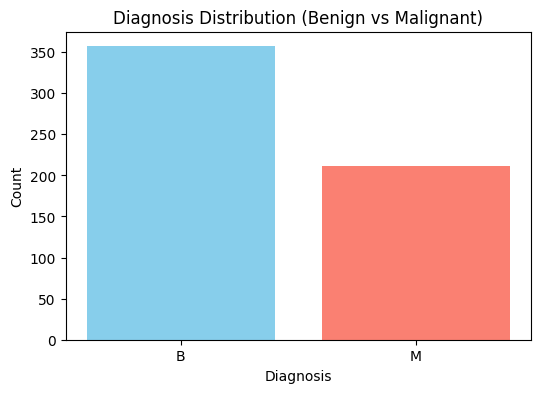

In [ ]:
# Task 2: Explore the Dataset

# 1. Missing value checks
print("=== Missing Values ===")
print(df.isnull().sum())

# 2. Summary statistics
print("\n=== Summary Statistics ===")
display(df.describe())

# 3. Feature dimensions
print("\n=== Feature Dimensions ===")
print(f"Rows (Samples): {df.shape[0]}, Columns (Features): {df.shape[1]}")

# 4. Diagnosis class distribution
print("\n=== Diagnosis Class Distribution ===")
distribution = df['diagnosis'].value_counts()
print(distribution)

# Simple bar plot to visualize diagnosis distribution
plt.figure(figsize=(6, 4))
plt.bar(distribution.index, distribution.values, color=['skyblue', 'salmon'])
plt.title('Diagnosis Distribution (Benign vs Malignant)')
plt.ylabel('Count')
plt.xlabel('Diagnosis')
plt.show()

# Task 3: Preprocess and Scale Features

* Select numerical features and drop non-informative identifiers (such as id).

* Apply StandardScaler to normalize feature magnitudes prior to graph distance calculation.

In [ ]:
# Task 3: Preprocess and Scale Features

# Separate targets/identifiers from features
# Features are all numeric columns except 'id' and 'diagnosis'
feature_cols = [col for col in df.columns if col not in ['id', 'diagnosis']]

X_raw = df[feature_cols]
y_true = df['diagnosis'].map({'M': 0, 'B': 1}) # Map target classes to numeric labels for evaluation

# Standardize features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Preprocessed feature shape: {X_scaled.shape}")
print("Feature Scaling Completed.")

Preprocessed feature shape: (569, 30)
Feature Scaling Completed.


# Task 4: Construct Pairwise Distance Matrix & Graph

* Compute pairwise Euclidean distance matrix across all scaled samples using scipy.spatial.distance.pdist or cdist.

* Represent the dataset as a weighted complete graph.

In [ ]:
# Task 4: Construct Pairwise Distance Matrix & Graph

# Compute pairwise Euclidean distances
pairwise_distances = pdist(X_scaled, metric='euclidean')

# Convert to a square symmetric distance matrix representing our weighted complete graph
distance_matrix = squareform(pairwise_distances)

print(f"Distance matrix shape: {distance_matrix.shape}")
print(f"Weighted Complete Graph created with {distance_matrix.shape[0]} nodes.")

Distance matrix shape: (569, 569)
Weighted Complete Graph created with 569 nodes.


# Task 5: Compute the Minimum Spanning Tree (MST)

* Compute the MST using scipy.sparse.csgraph.minimum_spanning_tree or networkx.minimum_spanning_tree.

* Extract the resulting graph connections and weights.

In [ ]:
# Task 5: Compute the Minimum Spanning Tree (MST)

# Compute the MST using scipy's minimum_spanning_tree
mst_sparse = minimum_spanning_tree(distance_matrix)

# Convert sparse representation back to dense array for edge analysis
mst_dense = mst_sparse.toarray()

# Extract edge connections (pairs of node indices) and their weights
edges = []
num_nodes = mst_dense.shape[0]
for i in range(num_nodes):
    for j in range(num_nodes):
        if mst_dense[i, j] > 0:
            edges.append((i, j, mst_dense[i, j]))

# Convert to DataFrame for easier inspection and sorting
edges_df = pd.DataFrame(edges, columns=['Node_A', 'Node_B', 'Weight'])
print(f"Number of edges in the MST: {len(edges_df)}")
display(edges_df.head(10))

Number of edges in the MST: 568


,Node_A,Node_B,Weight
0,0,77,4.829950
1,1,365,2.287051
2,2,45,2.676261
3,2,77,3.705644
4,2,535,2.451541
5,3,190,7.871039
6,4,498,2.882669
7,5,8,2.695145
8,5,31,3.069861
9,5,47,2.502851


# Task 6: Implement Graph-Based Clustering ($K=2$)

* Sort the edges of the MST in descending order by edge weight.
* Remove the largest $K - 1$ edge (1 largest edge for 2 clusters) to split the MST into 2 connected components.
* Assign final cluster labels based on the resulting component indices.


In [ ]:
# Task 6: Implement Graph-Based Clustering (K=2)

# Build the networkx graph representing our computed MST
G_mst = nx.Graph()
for u, v, w in edges:
    G_mst.add_edge(u, v, weight=w)

# Sort the edges in descending order by weight
sorted_edges = sorted(G_mst.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)

# Cut the single largest edge (K - 1 cut) to create K=2 connected components
if len(sorted_edges) > 0:
    largest_edge = sorted_edges[0]
    print(f"Largest edge removed: Node {largest_edge[0]} to Node {largest_edge[1]} with weight: {largest_edge[2]['weight']:.4f}")
    G_mst.remove_edge(largest_edge[0], largest_edge[1])

# Identify connected components
components = list(nx.connected_components(G_mst))
print(f"Number of resulting components (clusters): {len(components)}")

# Map each node to its corresponding cluster label (0 or 1)
y_pred = np.zeros(num_nodes, dtype=int)
for cluster_id, component in enumerate(components):
    for node in component:
        y_pred[node] = cluster_id

print("Cluster labels assigned successfully.")

Largest edge removed: Node 461 to Node 503 with weight: 12.2999
Number of resulting components (clusters): 2
Cluster labels assigned successfully.


# Task 7: valuate MST Clustering Performance

Evaluate cluster assignment against ground truth labels using:

  *  Silhouette Score

  *  Adjusted Rand Index (ARI)

  *  Normalized Mutual Information (NMI)

In [ ]:
# Task 7: Evaluate MST Clustering Performance

# Evaluate cluster quality and agreement with ground-truth classes
sil_score = silhouette_score(X_scaled, y_pred)
ari_score = adjusted_rand_score(y_true, y_pred)
nmi_score = normalized_mutual_info_score(y_true, y_pred)

print("=== Clustering Evaluation Metrics ===")
print(f"Silhouette Score:          {sil_score:.4f}")
print(f"Adjusted Rand Index (ARI):  {ari_score:.4f}")
print(f"Normalized Mutual Info:     {nmi_score:.4f}")

=== Clustering Evaluation Metrics ===
Silhouette Score:          0.6607
Adjusted Rand Index (ARI):  0.0048
Normalized Mutual Info:     0.0102


# Task 8: Visualize MST and Graph-Based Clusters

* Select two representative features (e.g., mean radius vs. mean texture) for 2D plotting.
 * Plot 1: Unclustered standardized data points.
* Plot 2: Minimum Spanning Tree (MST) edge connections overlaid on the data.
* Plot 3: Final clusters formed after cutting the $K - 1$ largest edge(s).

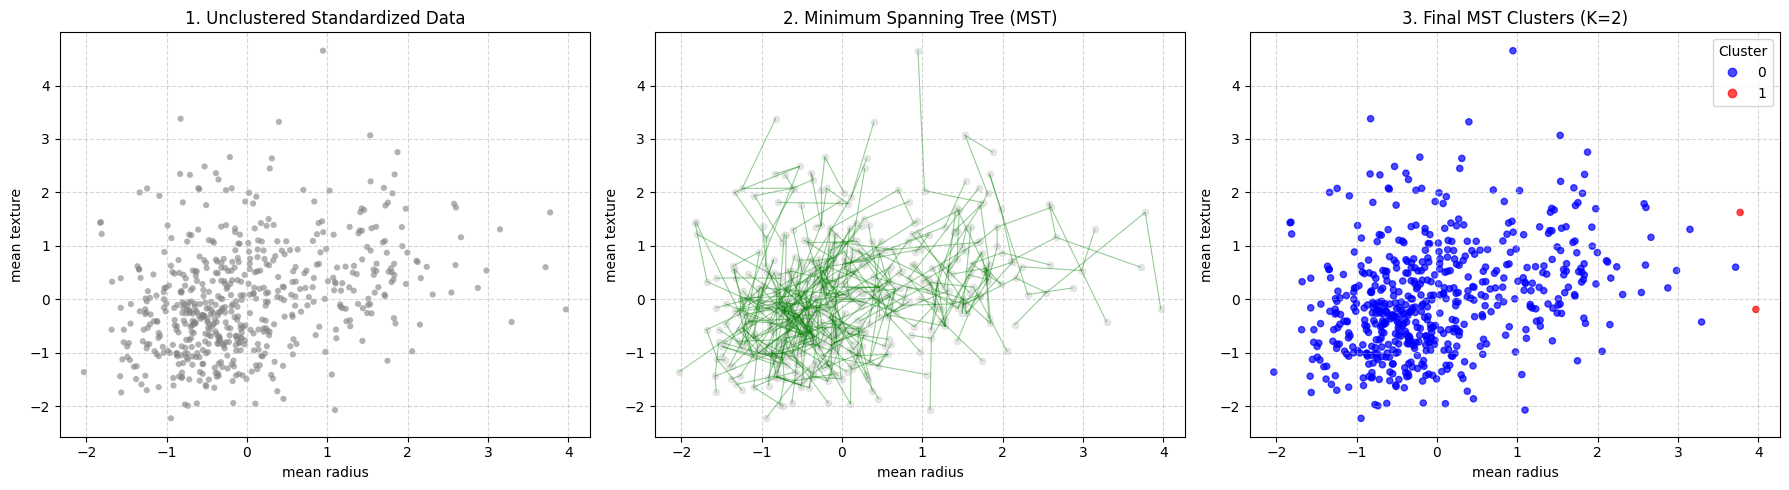

In [ ]:
# Task 8: Visualize MST and Graph-Based Clusters

# Selecting two representative features for plotting (e.g., column index 0 and 1, mean radius vs. mean texture)
feat1_idx = 0
feat2_idx = 1
x1 = X_scaled[:, feat1_idx]
x2 = X_scaled[:, feat2_idx]
xlabel = feature_cols[feat1_idx]
ylabel = feature_cols[feat2_idx]

plt.figure(figsize=(18, 5))

# Plot 1: Unclustered standardized data points
plt.subplot(1, 3, 1)
plt.scatter(x1, x2, c='gray', alpha=0.6, edgecolors='none', s=20)
plt.title("1. Unclustered Standardized Data")
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.grid(True, linestyle='--', alpha=0.5)

# Plot 2: Minimum Spanning Tree (MST) connections overlaid
plt.subplot(1, 3, 2)
plt.scatter(x1, x2, c='lightgray', alpha=0.5, s=20)
for u, v, _ in edges:
    plt.plot([x1[u], x1[v]], [x2[u], x2[v]], color='green', alpha=0.4, linewidth=0.8)
plt.title("2. Minimum Spanning Tree (MST)")
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.grid(True, linestyle='--', alpha=0.5)

# Plot 3: Final clusters formed after cutting the largest edge
plt.subplot(1, 3, 3)
scatter = plt.scatter(x1, x2, c=y_pred, cmap='bwr', alpha=0.7, s=20)
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.title("3. Final MST Clusters (K=2)")
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Conclusion

The experiment successfully demonstrated the implementation of Graph-Based Clustering using a Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset. The dataset was preprocessed, cleaned, and standardized before computing pairwise distances. The MST was generated, and by removing the largest edge(s), clusters representing tumor categories were obtained, evaluated using clustering metrics, and visualized.